In [23]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent
prices = pd.read_csv(ROOT / "data" / "clean_data.csv")
signals = pd.read_csv(ROOT / "data" / "signals_strategy_1.csv")

In [24]:
df = prices.merge(
    signals,
    on="Date",
    how="inner"
)
print(df.head())

   Unnamed: 0        Date        Close         High          Low         Open  \
0           1  2010-01-05  5277.899902  5288.350098  5242.399902  5277.149902   
1           2  2010-01-06  5281.799805  5310.850098  5260.049805  5278.149902   
2           3  2010-01-07  5263.100098  5302.549805  5244.750000  5281.799805   
3           4  2010-01-08  5244.750000  5276.750000  5234.700195  5264.250000   
4           5  2010-01-11  5249.399902  5287.200195  5227.799805  5263.799805   

   Volume       State_0   State_1        State_2  State_3        State_4  \
0       0  1.952660e-19  1.000000  1.856756e-110      0.0  6.670687e-102   
1       0  1.898562e-02  0.938718   4.202498e-02      0.0   2.714185e-04   
2       0  1.185316e-03  0.901994   9.648806e-02      0.0   3.324230e-04   
3       0  1.144737e-02  0.769153   2.190192e-01      0.0   3.804683e-04   
4       0  3.967511e-03  0.969593   2.469168e-02      0.0   1.747485e-03   

   Target_Position  Trade_Size  
0         0.850000    0

In [25]:
df["Return"] = df["Close"].pct_change()

print(df[["Date","Close","Return"]].head(10))

         Date        Close    Return
0  2010-01-05  5277.899902       NaN
1  2010-01-06  5281.799805  0.000739
2  2010-01-07  5263.100098 -0.003540
3  2010-01-08  5244.750000 -0.003487
4  2010-01-11  5249.399902  0.000887
5  2010-01-12  5210.399902 -0.007429
6  2010-01-13  5233.950195  0.004520
7  2010-01-14  5259.899902  0.004958
8  2010-01-15  5252.200195 -0.001464
9  2010-01-18  5274.850098  0.004312


In [26]:
df["Strategy_Return"] = (
    df["Target_Position"].shift(1)
    * df["Return"]
)

df["Strategy_Return"] = (
    df["Strategy_Return"]
    .fillna(0)
)

print(df[["Date","Return","Target_Position","Strategy_Return"]].head(10))

         Date    Return  Target_Position  Strategy_Return
0  2010-01-05       NaN         0.850000         0.000000
1  2010-01-06  0.000739         0.817004         0.000628
2  2010-01-07 -0.003540         0.768013        -0.002893
3  2010-01-08 -0.003487         0.665380        -0.002678
4  2010-01-11  0.000887         0.828821         0.000590
5  2010-01-12 -0.007429         0.102050        -0.006158
6  2010-01-13  0.004520         0.848443         0.000461
7  2010-01-14  0.004958         0.954008         0.004207
8  2010-01-15 -0.001464         0.806453        -0.001397
9  2010-01-18  0.004312         0.848686         0.003478


In [27]:
df["Equity"] = (
    1 + df["Strategy_Return"]
).cumprod()

print(
    df[["Date","Equity"]]
    .head(10)
)

         Date    Equity
0  2010-01-05  1.000000
1  2010-01-06  1.000628
2  2010-01-07  0.997734
3  2010-01-08  0.995062
4  2010-01-11  0.995649
5  2010-01-12  0.989518
6  2010-01-13  0.989975
7  2010-01-14  0.994139
8  2010-01-15  0.992751
9  2010-01-18  0.996203


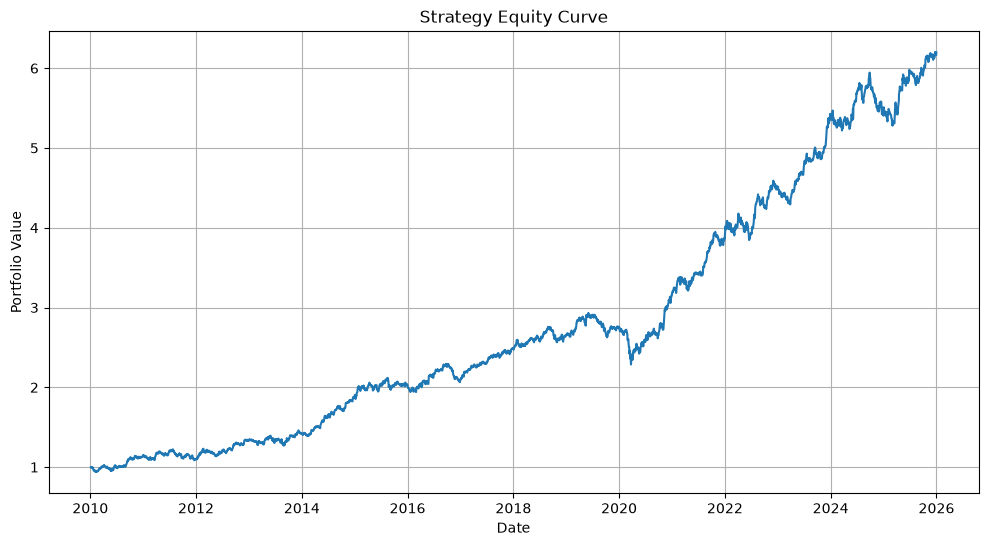

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df["Date"] = pd.to_datetime(df["Date"])

plt.plot(
    df["Date"],
    df["Equity"]
)

plt.title("Strategy Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

In [29]:
years = (
    (df["Date"].iloc[-1] - df["Date"].iloc[0])
    .days
    / 365.25
)

final_equity = df["Equity"].iloc[-1]

cagr = (
    final_equity ** (1 / years)
    - 1
)

print(f"CAGR: {cagr:.2%}")

CAGR: 12.09%


In [30]:
sharpe = (
    df["Strategy_Return"].mean()
    /
    df["Strategy_Return"].std()
) * (252 ** 0.5)

print(f"Sharpe Ratio: {sharpe:.2f}")

Sharpe Ratio: 1.23


In [31]:
df["Rolling_Max"] = (
    df["Equity"]
    .cummax()
)

df["Drawdown"] = (
    df["Equity"]
    /
    df["Rolling_Max"]
    - 1
)

max_drawdown = (
    df["Drawdown"]
    .min()
)

print(
    f"Max Drawdown: {max_drawdown:.2%}"
)

Max Drawdown: -22.03%


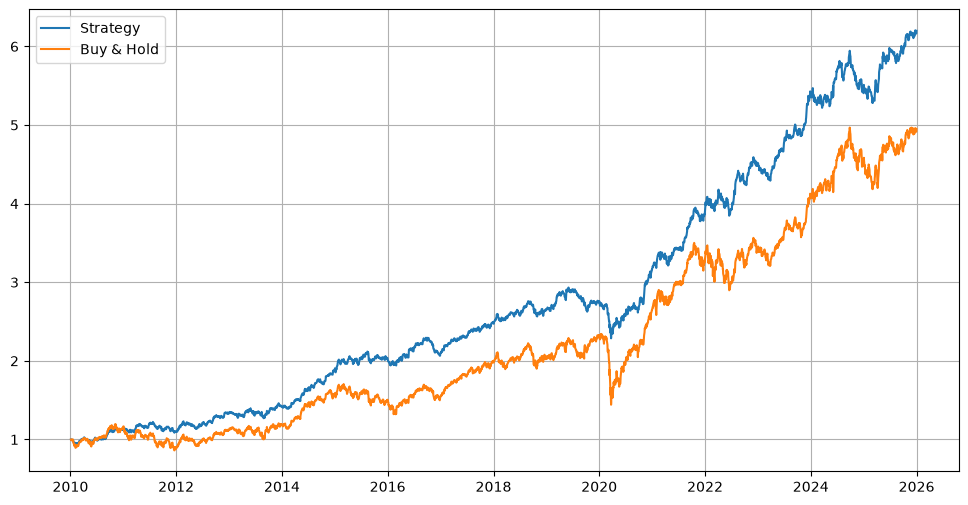

In [32]:
df["Market_Equity"] = (
    1 + df["Return"].fillna(0)
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Equity"], label="Strategy")
plt.plot(df["Date"], df["Market_Equity"], label="Buy & Hold")

plt.legend()
plt.grid(True)
plt.show()

In [33]:
changes = signals["Target_Position"].diff().abs().dropna()
signals = pd.read_csv(ROOT / "data" / "signals_strategy_1.csv")

print("Position change distribution:")
print(f"  Changes > 0.10 : {(changes > 0.10).sum()} ({(changes > 0.10).mean():.1%} of days)")
print(f"  Changes > 0.50 : {(changes > 0.50).sum()} ({(changes > 0.50).mean():.1%} of days)")
print(f"  Changes > 0.80 : {(changes > 0.80).sum()} ({(changes > 0.80).mean():.1%} of days)")
print(f"  Mean change    : {changes.mean():.4f}")

Position change distribution:
  Changes > 0.10 : 2431 (61.9% of days)
  Changes > 0.50 : 1094 (27.9% of days)
  Changes > 0.80 : 488 (12.4% of days)
  Mean change    : 0.3107


In [34]:

prices = pd.read_csv(ROOT / "data" / "clean_data.csv")
signals = pd.read_csv(ROOT / "data" / "signals_strategy_1.csv")

df = prices.merge(signals, on="Date", how="inner")
df["Date"]   = pd.to_datetime(df["Date"])
df["Return"] = df["Close"].pct_change()
df["Year"]   = df["Date"].dt.year

df["Position"] = df["Target_Position"].shift(1).fillna(0)
df["Strat_Return"] = df["Position"] * df["Return"]

annual = df.groupby("Year").apply(lambda g: pd.Series({
    "Strategy" : (1 + g["Strat_Return"]).prod() - 1,
    "BH"       : (1 + g["Return"].fillna(0)).prod() - 1,
    "Avg_Pos"  : g["Position"].mean(),
}))
print(annual.round(3))

      Strategy     BH  Avg_Pos
Year                          
2010     0.149  0.162    0.626
2011    -0.047 -0.246    0.512
2012     0.215  0.277    0.663
2013     0.072  0.068    0.587
2014     0.320  0.314    0.656
2015     0.080 -0.041    0.599
2016     0.034  0.030    0.597
2017     0.186  0.286    0.674
2018     0.067  0.032    0.613
2019     0.031  0.120    0.595
2020     0.155  0.149    0.599
2021     0.229  0.241    0.628
2022     0.157  0.043    0.611
2023     0.204  0.200    0.657
2024    -0.002  0.088    0.648
2025     0.147  0.105    0.639
